In [1]:
!pip install split-folders tensorflowjs

import zipfile
import os
import splitfolders
import tensorflow as tf
import matplotlib.pyplot as plt
import pathlib
import numpy as np

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Ekstrasi file zip
local_zip = '/content/dataset CNN - garbage dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/datasetGarbage_asli')
zip_ref.close()

print("Isi folder ekstraksi:", os.listdir('/content/datasetGarbage_asli'))

Isi folder ekstraksi: ['garbage_classification_corrected', 'garbage_classification_enhanced', 'labels_corrections.csv']


In [3]:
# memperbarui base_dir dengan menyambungkan path ekstraksi dan nama folder hasil ekstrasi
base_dir = '/content/datasetGarbage_asli/garbage_classification_enhanced'
print("Daftar kelas 1:", os.listdir(base_dir))

base_dir = '/content/datasetGarbage_asli/garbage_classification_corrected'
print("Daftar kelas 2:", os.listdir(base_dir))

Daftar kelas 1: ['brown-glass', 'shoes', 'cardboard', 'white-glass', 'trash', 'plastic', 'metal', 'clothes', 'biological', 'green-glass', 'paper', 'battery']
Daftar kelas 2: ['brown-glass', 'shoes', 'cardboard', 'white-glass', 'trash', 'plastic', 'metal', 'clothes', 'biological', 'green-glass', 'paper', 'battery']


In [4]:
splitfolders.ratio(base_dir, output="/content/dataset_final", seed=1337, ratio=(.8, .1, .1))

train_dir = '/content/dataset_final/train'
val_dir = '/content/dataset_final/val'
test_dir = '/content/dataset_final/test'

print("Dataset berhasil dibagi!")

Copying files: 15467 files [00:07, 2147.28 files/s]

Dataset berhasil dibagi!


In [5]:
# Augmentasi untuk data latih
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 12368 images belonging to 12 classes.
Found 1541 images belonging to 12 classes.
Found 1558 images belonging to 12 classes.


In [6]:
# Penggunaab arsitektur MobileNetV2 agar model ini lebih baik kinerjanya untuk mengenal gambar
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(150, 150, 3))

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

num_classes = len(train_generator.class_indices)

model = tf.keras.models.Sequential([
    base_model,

    # TAMBAHAN LAYER SESUAI KRITERIA 4
    # saya sudah tambahkan 512 filter Conv2D dan layer Pooling
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

/tmp/ipython-input-1952151021.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet',


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 512)      │     5,898,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         6,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,425,548 (32.14 MB)

 Trainable params: 7,373,644 (28.13 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [7]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
      print("\nAkurasi telah mencapai >95%!")
      self.model.stop_training = True

callbacks = myCallback()

# Mulai training (1 epoch bisa memakan waktu kira2 20  menit)
history = model.fit(
    train_generator,
    epochs=20, # diatur agar mencapai 95%, bismillah
    validation_data=val_generator,
    callbacks=[callbacks]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 144s 305ms/step - accuracy: 0.6921 - loss: 1.2446 - val_accuracy: 0.5120 - val_loss: 8.7811
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 83s 214ms/step - accuracy: 0.8739 - loss: 0.4619 - val_accuracy: 0.3829 - val_loss: 110.1942
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 83s 214ms/step - accuracy: 0.8944 - loss: 0.3617 - val_accuracy: 0.5581 - val_loss: 14.7799
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 83s 215ms/step - accuracy: 0.9170 - loss: 0.2986 - val_accuracy: 0.7229 - val_loss: 7.6260
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 84s 217ms/step - accuracy: 0.9302 - loss: 0.2516 - val_accuracy: 0.8968 - val_loss: 0.4363
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - accuracy: 0.9372 - loss: 0.2182 - val_accuracy: 0.8903 - val_loss: 0.4682
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.9447 - loss: 0.1914 - val_accuracy: 0.9150 - val_loss: 0.3770
Epoch 8/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 83s 215ms/step - accuracy: 0.9387 - los

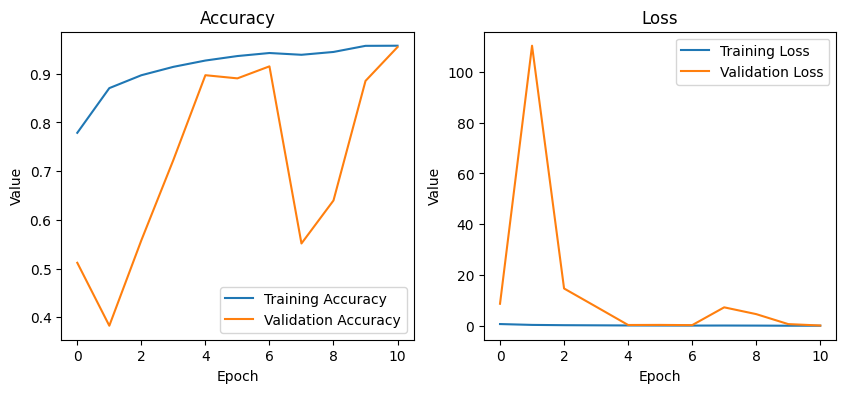


Evaluasi Model pada Test Set:
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.9310 - loss: 0.3008


[0.3196638822555542, 0.9274711012840271]

In [8]:
# Plot Akurasi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend(loc="lower right")

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend(loc="upper right")
plt.show()

# Evaluasi ke Test Set
print("\nEvaluasi Model pada Test Set:")
model.evaluate(test_generator)

In [9]:
# Simpan format SavedModel
export_dir = 'saved_model/'
model.export(export_dir)

# Convert ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('tflite/model.tflite')
tflite_model_file.parent.mkdir(parents=True, exist_ok=True)
tflite_model_file.write_bytes(tflite_model)

# Buat file label.txt untuk TFLite
labels = '\n'.join(sorted(train_generator.class_indices.keys()))
with open('tflite/label.txt', 'w') as f:
    f.write(labels)

# Convert ke TFJS
!tensorflowjs_converter --input_format=tf_saved_model /content/saved_model /content/tfjs_model

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  135742066329552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066330896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066333584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066333200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066332048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066333776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066334352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066333968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135742066331856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1357420663303

Saving OIP (3).jfif to OIP (3) (2).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
OIP (3) (2).jfif
Gambar ini diprediksi sebagai: trash


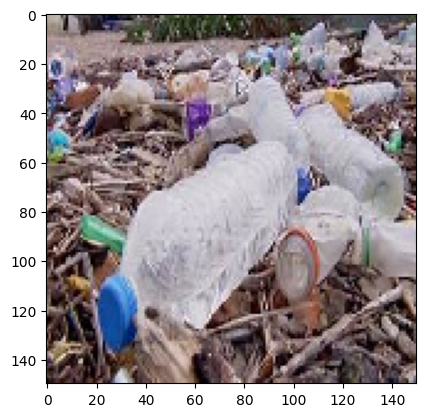

In [13]:
uploaded = files.upload()

for fn in uploaded.keys():
  path = fn
  img = image.load_img(path, target_size=(150, 150))
  imgplot = plt.imshow(img)
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  print(fn)
  # Mengambil indeks dengan probabilitas tertinggi
  class_idx = np.argmax(classes)
  class_labels = list(train_generator.class_indices.keys())
  print(f"Gambar ini diprediksi sebagai: {class_labels[class_idx]}")